# TRAWLING4PACE 
## Fish-PACE Hackweek 1/26/26-1/30/26
<p style="font-size: 40px;">

    
**Project members:** 
* Mary Kate Munley (NOAA Fisheries NEFSC / Saltwater Inc)
* Justine Whitaker (University of Maryland Eastern Shore)
* Victoria Abunaw (Univeristy of Rhode Island)
* Punya Puthukulangara (Indian Institutde of Space Science and Technology)
* Frederic Bonou (National University of Sciences, Technologies, Engineering and Mathematics / Benin Fisheries and Oceanological Research Institute)
* Leandro Machado Cruz (Instituto de Estudos do Mar Almirante Paulo Moreira)
* Haley Synan (NOAA Fisheries NEFSC / IBSS)  <br>

**Research question:** <br>
Can PACE data be used as predictors for catch abundance for Silver Hake in the NorthWest Atlantic? <br>


**Why include optical data?:** <br>
1. Integrates biological data, not just physical data in the model 
2. High spatial and temporal resolution <br>


**Datasets**:
* NOAA NEFSC Bottom Trawl Survey Data (Spring 2024, Fall 2024, Spring 2025)
* [PACE L3M Rrs](https://www.earthdata.nasa.gov/data/catalog/ob-cloud-pace-oci-l3m-rrs-3.1)
* [AVISO Finite-Size Lyapunov Exponents (FSLE)](https://www.google.com/search?q=aviso+fsle): Lagrangian diagnostic that identify regions where the stretching induced by altimetry-detected mesoscale velocities is strong. For our purposes here, they are helpful in finding nutrient-rich convergence zones (where fish may be) and water mass boundaries
* [Copernicus wind stress curl](https://data.marine.copernicus.eu/product/WIND_GLO_PHY_L4_MY_012_006/description): The spatial variation (rotation) of wind stress over the ocean surface, acting as a fundamental, large-scale driving force for ocean circulation. 
</p>



## Table of contents
*Note: If you are working in a jupyter environment with this notebook downloaded, this TOC is interactive. However, it is not interactive on the github webpage*
#### 1. [Load data](#load_data)
#### 2. [Data cleaning](#clean_data)
#### 3. [Split data](#split_data)
#### 4. [Data imputation](#Data_imputation)
#### 5. [Model training](#model_training)
#### &emsp; 5a. [Boosted regression tree](#brt)
#### &emsp;&emsp; 5aa. [Feature selection](#fs)
#### &emsp;&emsp; 5ba. [Hyper-parameterization](#brt_hp)
#### &emsp;&emsp; 5bb. [Final modeling training](#brt_fm)
#### &emsp;&emsp; 5bc. [Feature importance](#brt_fi)
#### &emsp;&emsp; 5bd. [Predict catch abundance](#brt_pa)
#### 6. [Visualize results](#vr)
#### &emsp; 6a. [Mapped abundance predictions](#mar)
#### &emsp; 6b. [Mapped Residuals](#mr)
#### 7. [Interpret results](#ir)
#### &emsp; 7a. [Partial depedence plots](#ppd)
#### &emsp; 7b. [Bland Altman plots](#ba)
#### &emsp; 7c. [SHAP](#shap)
#### 8. [Statistical Analysis](#sa)
#### &emsp; 8a. [Check for overfitting](#of)
#### &emsp; 8b. [Cross-validation](#cv)
#### 9. [Conclusions](#conc)
#### 10. [Definitions](#def)

In [1]:
!pip install shap

  Using cached shap-0.51.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import os
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import datetime
import numpy as np
import cartopy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import cartopy
from sklearn.inspection import PartialDependenceDisplay
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score


## Load data <a id="load_data"></a>

The fish catch data we are using for this project is the NOAA NEFSC Bottom Trawl Survey Data. We are only using the surveys that coincide with the PACE timeline, Spring 2024, Fall 2024, and Spring 2025. 
For remotely-sensed data, we are using matched Rrs (L3m) data from PACE, wind stress curl from Copernicus, and FSLE from Aviso. <br>
Note: the match-up code is not shown in this notebook, but can be found in ```/2026-proj-Trawling4PACE/contributer_folders/leandro/download_*.ipynb``` for the non-PACE remotely-sensed variables. Match-up code demonstrated in the [Match-up basics - Points and PACE](https://fish-pace.github.io/hackweek-2025/presentations/notebooks/matchups.html) tutorial were adapted for our catch data. 


In [4]:
# LOAD DATA
# ---------------------------------------------------
url = (
    "https://raw.githubusercontent.com/"
    "fish-pace/2026-proj-Trawling4PACE/main/"
    "data/Test_PACE_RRS_AVW_CHL_1D_centerpixel.csv"
)
df= pd.read_csv(url) #open BTS matched with PACE data
df =df[df.SCIENTIFIC_NAME=='Merluccius bilinearis (silver hake)'] #filter only silver hake catch data
df=df.dropna(subset=['avw_0','chlor_a_0']) #filter out nans
url = (
    "https://raw.githubusercontent.com/"
    "fish-pace/2026-proj-Trawling4PACE/main/"
    "contributor_folders/leandro/correlation_data.csv"
)
df1= pd.read_csv(url)
#check duplicates
df.groupby(['DECDEG_ENDLAT','DECDEG_ENDLON']).size().sort_values(ascending=False).head()
df1.groupby(['DECDEG_ENDLAT','DECDEG_ENDLON']).size().sort_values(ascending=False).head()
#Diagnose near duplicate rows values
df[['DECDEG_ENDLAT','DECDEG_ENDLON']].nunique()
#Select numeric columns explicitly
num_cols = df.select_dtypes(include='number').columns
num_cols1 = df1.select_dtypes(include='number').columns
#Aggregate
df1_agg = (
    df
    .groupby(['DECDEG_ENDLAT', 'DECDEG_ENDLON','BEGIN_GMT_TOWDATE'], as_index=False)[num_cols]
    .mean()
)

df2_agg = (
    df1
    .groupby(['DECDEG_ENDLAT', 'DECDEG_ENDLON','BEGIN_GMT_TOWDATE'], as_index=False)[num_cols1]
    .mean()
)

# Merge
df= pd.merge(df1_agg, df2_agg, on=['DECDEG_ENDLAT','DECDEG_ENDLON','BEGIN_GMT_TOWDATE']) #merge dataframes together based on station (ie lat/lon/time)
df=df.rename(columns={'SURFTEMP_x':'SURFTEMP', 'SURFSALIN_x':'SURFSALIN', 'BOTTEMP_x':'BOTTEMP', 'BOTSALIN_x':'BOTSALIN'}) #rename columns as necessary 

In [5]:
df

,BEGIN_GMT_TOWDATE,Original_Index,CRUISE6,CRUISE,STRATUM,TOW,STATION,TOWDUR,SETDEPTH,ENDDEPTH,...,SURFTEMP_y,EXPCATCHNUM_log,EXPCATCHWT_log,curl_stress_curl,fsle_fsle_max,glorys_bottomT_surface,glorys_mlotst_surface,glorys_so_surface,glorys_thetao_bottom,glorys_thetao_surface
0,03/13/2025 04:47:00,11755.0,202502.0,202502.0,1630.0,2.0,111.0,20.14,175.0,174.0,...,NaN,1.020126,-0.359909,7.328962e-07,NaN,8.581912,22.644948,36.336998,NaN,20.775037
1,03/12/2025 23:08:47,11818.0,202502.0,202502.0,1640.0,2.0,105.0,20.00,189.0,189.0,...,NaN,0.877131,-0.255150,3.198777e-07,NaN,9.000576,20.583135,35.963439,NaN,18.704265
2,03/12/2025 20:43:21,11776.0,202502.0,202502.0,1630.0,3.0,102.0,20.07,124.0,120.0,...,NaN,0.750246,0.052977,2.446841e-07,NaN,8.269540,20.015850,35.368134,NaN,16.303290
3,03/12/2025 15:50:49,12033.0,202502.0,202502.0,1670.0,1.0,99.0,20.00,133.0,131.0,...,NaN,0.942535,-0.076210,-6.784386e-08,-0.144487,6.201233,19.319585,35.056365,NaN,14.913328
4,03/12/2025 14:09:00,12130.0,202502.0,202502.0,1680.0,2.0,97.0,20.06,198.0,193.0,...,NaN,1.075611,0.071407,-1.030994e-07,-0.030036,6.047905,19.455072,34.986889,NaN,14.608598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,05/12/2025 18:09:13,11519.0,202502.0,202502.0,1390.0,3.0,755.0,19.08,95.0,91.0,...,NaN,0.955745,0.055479,2.611559e-07,NaN,5.287140,12.240265,31.537306,NaN,7.626852
188,05/11/2025 15:43:58,10775.0,202502.0,202502.0,1340.0,3.0,741.0,19.93,107.0,108.0,...,NaN,0.723122,-0.003839,4.288294e-07,NaN,6.486234,10.993789,32.460471,NaN,7.281606
189,05/11/2025 20:09:08,10913.0,202502.0,202502.0,1351.0,2.0,743.0,20.01,196.0,196.0,...,NaN,0.607389,0.085550,2.624396e-07,NaN,6.268296,10.706131,32.171354,NaN,7.071854
190,05/12/2025 02:46:17,10889.0,202502.0,202502.0,1351.0,1.0,747.0,20.03,155.0,153.0,...,NaN,0.865507,0.234202,2.612240e-06,NaN,6.458871,11.384435,32.174527,NaN,7.064060


## Data cleaning  <a id="clean_data"></a>
Here we need to split the datetime string into day, month, year, and day of year (doy). Note, in this specific case we don't have any absence data (may have been accidentally filtered out when matching or just doesn't exist in the raw data). However, if true zeros exist, you would want to incorporate that into the model.

In [7]:
# FEATURE ENGINEERING (DATE)
# ---------------------------------------------------
df['BEGIN_GMT_TOWDATE'] = pd.to_datetime(df['BEGIN_GMT_TOWDATE'])

df['month'] = df['BEGIN_GMT_TOWDATE'].dt.month
df['day']   = df['BEGIN_GMT_TOWDATE'].dt.day
df['year']  = df['BEGIN_GMT_TOWDATE'].dt.year
df['doy']   = df['BEGIN_GMT_TOWDATE'].dt.dayofyear
df['EXPCATCHNUM_log'] = np.log10(df.EXPCATCHNUM)

# REMOVE NaN TARGETS (CRITICAL)
#df = df.dropna(subset=['EXPCATCHNUM_log'])
df = df.replace([np.inf, -np.inf], 0)

# DEFINE FEATURES & TARGET
# ---------------------------------------------------
y = df['EXPCATCHNUM_log']
#subset by potential variables (Rrs and environmental)
rrs = list(df.filter(like='Rrs', axis=1).columns)
anc= ['BOTTEMP', 'BOTSALIN', 'MAXDEPTH', 'year', 'doy','fsle_fsle_max', 'curl_stress_curl']
var = anc+rrs
X = df[var]

## Split data <a id="split_data"></a>

We are predicting species abundance (catch number) and using other variables from the in-situ data and PACE as predictors. We then split the data into 80% as training data and 20% as testing data. <br>
NOTE: we are doing a random split here, but this is not the best way to split it. Instead, we should be splitting temporally, as oceanographic conditions are highly correlated in space and time. Splitting temporally prevents overfitting and ensures generalization and makes it more useful for predictions. Splitting the data randomly causes [data leakage](#data-leakage), which allows the model to learn from future or test-set information. However, here we are splitting the data randomly as there was very little training data and using only 2024 data would result it less than 100 observations for training. 
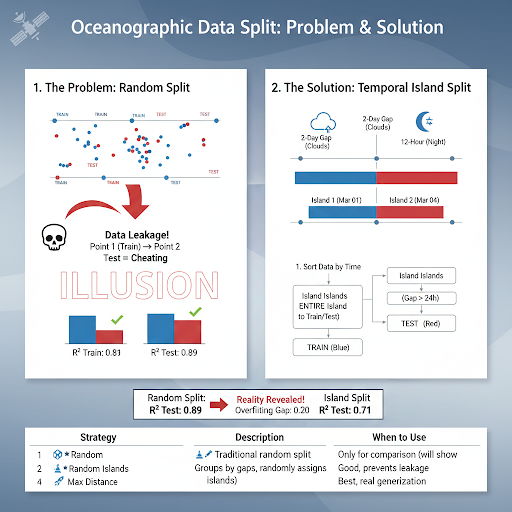

In [8]:
# TRAIN / TEST SPLIT
# RANDOM 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TEMPORALLY
#df=df.dropna(axis=1,how='all')
#X_train = df[df.year==2024].drop(columns=['EXPCATCHNUM_log','BEGIN_GMT_TOWDATE'])
#y_train = df[df.year==2024].EXPCATCHNUM_log
#X_test = df[df.year==2025].drop(columns=['EXPCATCHNUM_log','BEGIN_GMT_TOWDATE'])
#y_test = df[df.year==2025].EXPCATCHNUM_log
print(f'There are {len(X_train)} observations in the training dataset and {len(X_test)} observations in the test dataset')

There are 153 observations in the training dataset and 39 observations in the test dataset


## Data imputation <a id="Data_imputation"></a>
We are using [k nearest neighbor imputation](#K-nearest-neighbors-imputation) to fill missing data because we have such a small training dataset and are missing quite a bit of temperature and salinity data. However, this is going to give us a new source of uncertainty and error in the model (especially on such a small dataset with such a high # of missing data). 

In [9]:
print(f'{(X_train[['BOTSALIN']].isna().sum().values[0]/len(X_train)*100).round(3)}% of bottom salinity values are missing from the training data')
print(f'{(X_train[['BOTTEMP']].isna().sum().values[0]/len(X_train)*100).round(3)}% of bottom temperature values are missing from the training data')

50.98% of bottom salinity values are missing from the training data
50.98% of bottom temperature values are missing from the training data


In [10]:
# KNN IMPUTATION (FIT ON TRAIN ONLY) 
# 1. Initialize Scaler and Imputer
scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=5, weights='distance')

# 2. Fit and Transform the Train data
# We scale FIRST, then impute the missing values in the scaled space
X_train_scaled = scaler.fit_transform(X_train)
X_train_imputed_scaled = imputer.fit_transform(X_train_scaled)

# 3. Transform the Test data using the Train scale
X_test_scaled = scaler.transform(X_test)
X_test_imputed_scaled = imputer.transform(X_test_scaled)

# 4. "Unscale" back to original units 
X_train_imputed = pd.DataFrame(
    scaler.inverse_transform(X_train_imputed_scaled),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    scaler.inverse_transform(X_test_imputed_scaled),
    columns=X_test.columns,
    index=X_test.index
)

## **Boosted regression trees (BRT)** <a id="brt"></a>
Boosted regresion trees are a machine learning model for regression problems that combine [decision trees](#decision-trees) and [boosting](#boosting) to enhance predictive accuracy. By sequentially fitting new trees to model the residuals (errors) of previous trees, BRT effectively handles complex, nonlinear relationships, missing data, and varied predictor types without requiring data transformation. 
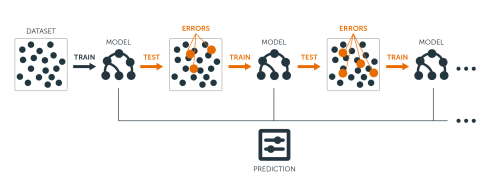

## [Feature](#feature) selection <a id="fs"></a>
Using all the Rrs wavelengths in the BRT would not be ideal in this case. We have a really small dataset, so we would have a really high ratio of observations to predictors. Additionally, using all the Rrs wavelengths would lead to [multicollinearity](#multicollinearity). The PACE Rrs wavelengths are at 2.5 nm steps, so many wavelengths are highly correlated. <br>
Instead, we will use a [ranking-based feature selection](#ranking-based-feature-selection) technique to find only the most informative Rrs wavelengths to use in the final model. 
We wll run an initial BRT on all the Rrs values (and ONLY Rrs values) and find the most important band. Next, a correlation matrix is made and all bands that have a >95% correlated with that band are dropped. Then the model is run again on the subset of Rrs values and the steps repeat until there are no Rrs bands left. 

Text(144.44444444444446, 0.5, 'Wavelength (Short -> Long)')

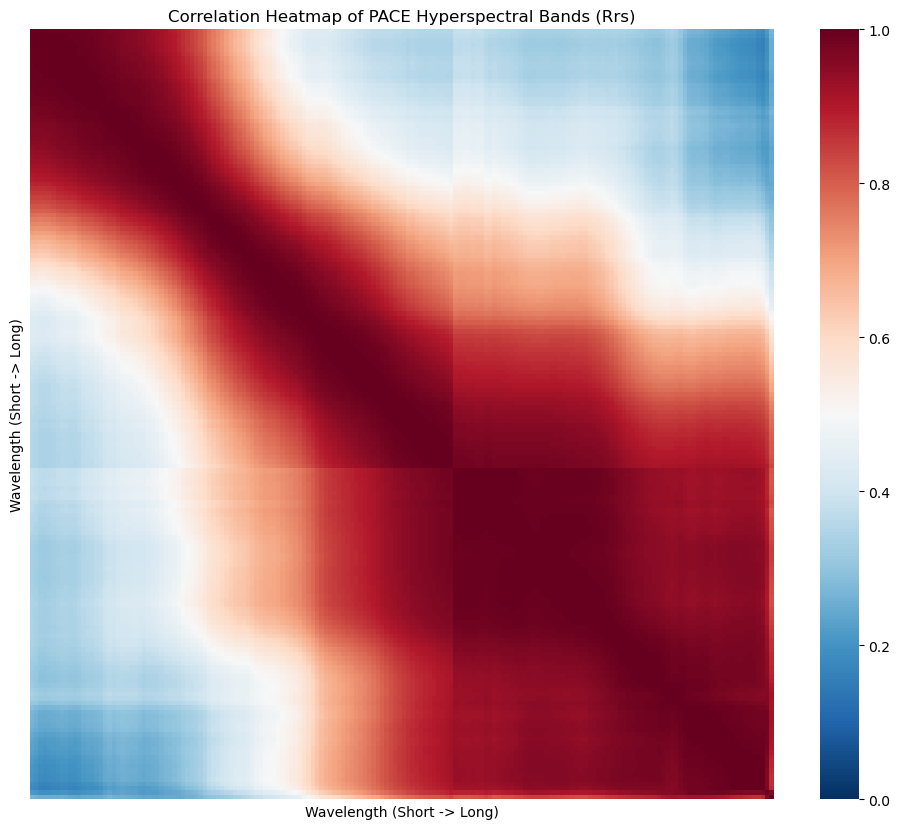

In [11]:
import seaborn as sns
rrs_cols = [col for col in df.columns if 'Rrs' in col]
rrs_data = df[rrs_cols]

# 2. Calculate the Pearson Correlation Matrix
corr_matrix = rrs_data.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            cmap='RdBu_r',   # Red-Blue palette (Red = +1, Blue = -1)
            center=0.5, 
            vmin=0, vmax=1,
            xticklabels=False, yticklabels=False) # Hide labels if >50 bands

plt.title('Correlation Heatmap of PACE Hyperspectral Bands (Rrs)')
plt.xlabel('Wavelength (Short -> Long)')
plt.ylabel('Wavelength (Short -> Long)')

In [12]:
#step 1: run the model
#step 2: get the most important Rrs band 
#step 3: remove all bands that are more than 0.95 correlated
#step 4: again
bands = []
rrs_cols = X_train_imputed.filter(like='Rrs', axis=1)
for x in range(10):
    try: 
        xgb_reg = xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=1000,
            learning_rate=0.01,
            subsample=0.8,
            colsample_bytree=0.5,
            n_jobs=-1,
            random_state=42
        )
        xgb_reg.fit(rrs_cols, y_train)
        
        # Get feature importances as a numpy array
        importances = xgb_reg.feature_importances_
        feature_names = rrs_cols.columns # Get feature names if X_train is a pandas DataFrame
        
        # Create a pandas DataFrame for a clear, sortable list
        xgb_feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        })
        
        # Sort and print the results
        xgb_feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
    
        corr_matrix=rrs_cols.corr()
        most_important=xgb_feature_importance_df.iloc[0].Feature
        cor = corr_matrix[most_important].sort_index()
        rrs_cols=X_train_imputed[list(cor.where(cor<0.95).dropna().keys())]
    
        bands.append(most_important)
        print(f'For iteration {x+1}, {most_important} was the most important wavelength')

    except IndexError:
        print(f'Band selection completed')
        break
        

For iteration 1, Rrs_452 was the most important wavelength
For iteration 2, Rrs_681 was the most important wavelength
For iteration 3, Rrs_525 was the most important wavelength
For iteration 4, Rrs_380 was the most important wavelength
For iteration 5, Rrs_573 was the most important wavelength
For iteration 6, Rrs_719 was the most important wavelength
For iteration 7, Rrs_425 was the most important wavelength
For iteration 8, Rrs_487 was the most important wavelength
Band selection completed


In [13]:
anc= ['BOTTEMP', 'BOTSALIN', 'MAXDEPTH', 'fsle_fsle_max', 'curl_stress_curl','doy']#'year', 
train_vars = anc+bands
print(f'Final features chosen to include in model training: {train_vars}')

Final features chosen to include in model training: ['BOTTEMP', 'BOTSALIN', 'MAXDEPTH', 'fsle_fsle_max', 'curl_stress_curl', 'doy', 'Rrs_452', 'Rrs_681', 'Rrs_525', 'Rrs_380', 'Rrs_573', 'Rrs_719', 'Rrs_425', 'Rrs_487']


### Hyperparameterization <a id="brt_hp"></a>
We are going to optimize 5 parameters: n_estimators, learning rate, max_depth, reg_alpha, and reg_lambda. <br>
*Note: definitions are taken from results of a google search of xgboost parameters* 
* **n_estimators**: number of decision trees
* **max_depth**: controls the maximum [depth](#depth) of each individual decision tree in the forest. Higher max_depth makes the model more complex, allowing the treesto capture more intricate patterns in the data, which increases likelihood of overfitting (and vice versa) 
* **learning rate**: controls the contribution of each individual tree to the final ensemble prediction. Slowing down the rate may prevent the model from fitting too quickly to the training data and overfitting. A lower learning rate typically requires a higher number of trees. 
* **reg_alpha**: L1 regularization term on the leaf weights. Increasing its value makes the model more conservative, helps prevent overfitting, and encourages sparsity in the model, meaning it pushes the weights of less important features or branches toward zero. This can lead to simpler and more generalizable models. The default value is 0, which means no L1 regularization is applied by default.
* **reg_lambda**: controls the L2 regularization term on the weights (scores) of the leaf nodes in the boosted regression trees. Increasing its value makes the model more conservative. 


In [14]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.05, 0.01],
    'max_depth': [1,2,3,],
    'reg_alpha': [0.0, 0.01, 0.05, 0.1],
    'reg_lambda': [0.1, 1, 2]
}

xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_imputed[train_vars], y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV neg-MSE:", grid_search.best_score_)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 1}
Best CV neg-MSE: -0.5682814398753224


### Train the final Boosted regression tree model based on results from the hyper-parameterization <a id="brt_fm"></a>

In [15]:
#del grid_search.best_params_['max_depth']
xgb_reg = xgb.XGBRegressor(
    **grid_search.best_params_,
    objective='reg:squarederror',
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    #max_depth=1,
    n_jobs=-1,
    random_state=42
)

xgb_reg.fit(X_train_imputed[train_vars], y_train)

print("Model training complete.")

Model training complete.


### Check feature importance <a id="brt_fi"></a>

Text(0.5, 1.0, 'Feature importance for Boosted Regression Tree')

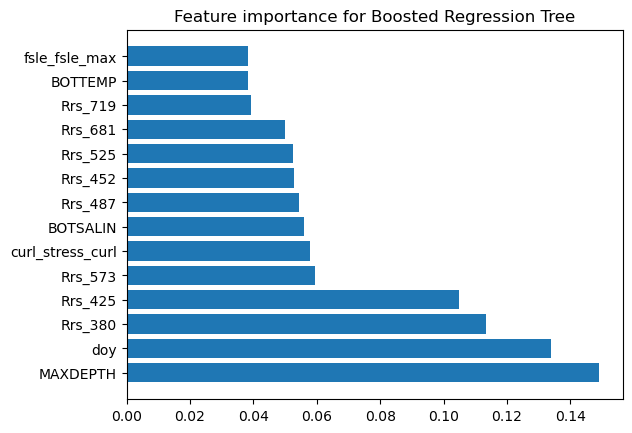

In [16]:
# Get feature importances as a numpy array
importances = xgb_reg.feature_importances_
feature_names = X_train[train_vars].columns # Get feature names if X_train is a pandas DataFrame

# Create a pandas DataFrame for a clear, sortable list
xgb_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort and print the results
xgb_feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

plt.barh(xgb_feature_importance_df.Feature, xgb_feature_importance_df['Importance'])
plt.title('Feature importance for Boosted Regression Tree')
#plt.savefig('/home/jovyan/2026-proj-Trawling4PACE/figures/BRT_feature_importance.jpg')

### Predict silver hake abundances <a id="brt_pa"></a>
And calculate performance metrics

In [17]:
predictions_brt = xgb_reg.predict(X_test_imputed[train_vars])

rmse = np.sqrt(mean_squared_error(y_test, predictions_brt))
r2 = r2_score(y_test, predictions_brt)

print(f"RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

RMSE: 0.8279
Test R²: 0.4274


# Results
## Visualize results <a id="vr"></a>
#### Mapped predicted abundance results <a id="mar"></a>

Text(0.5, 1.04, 'Silver Hake Abundance')

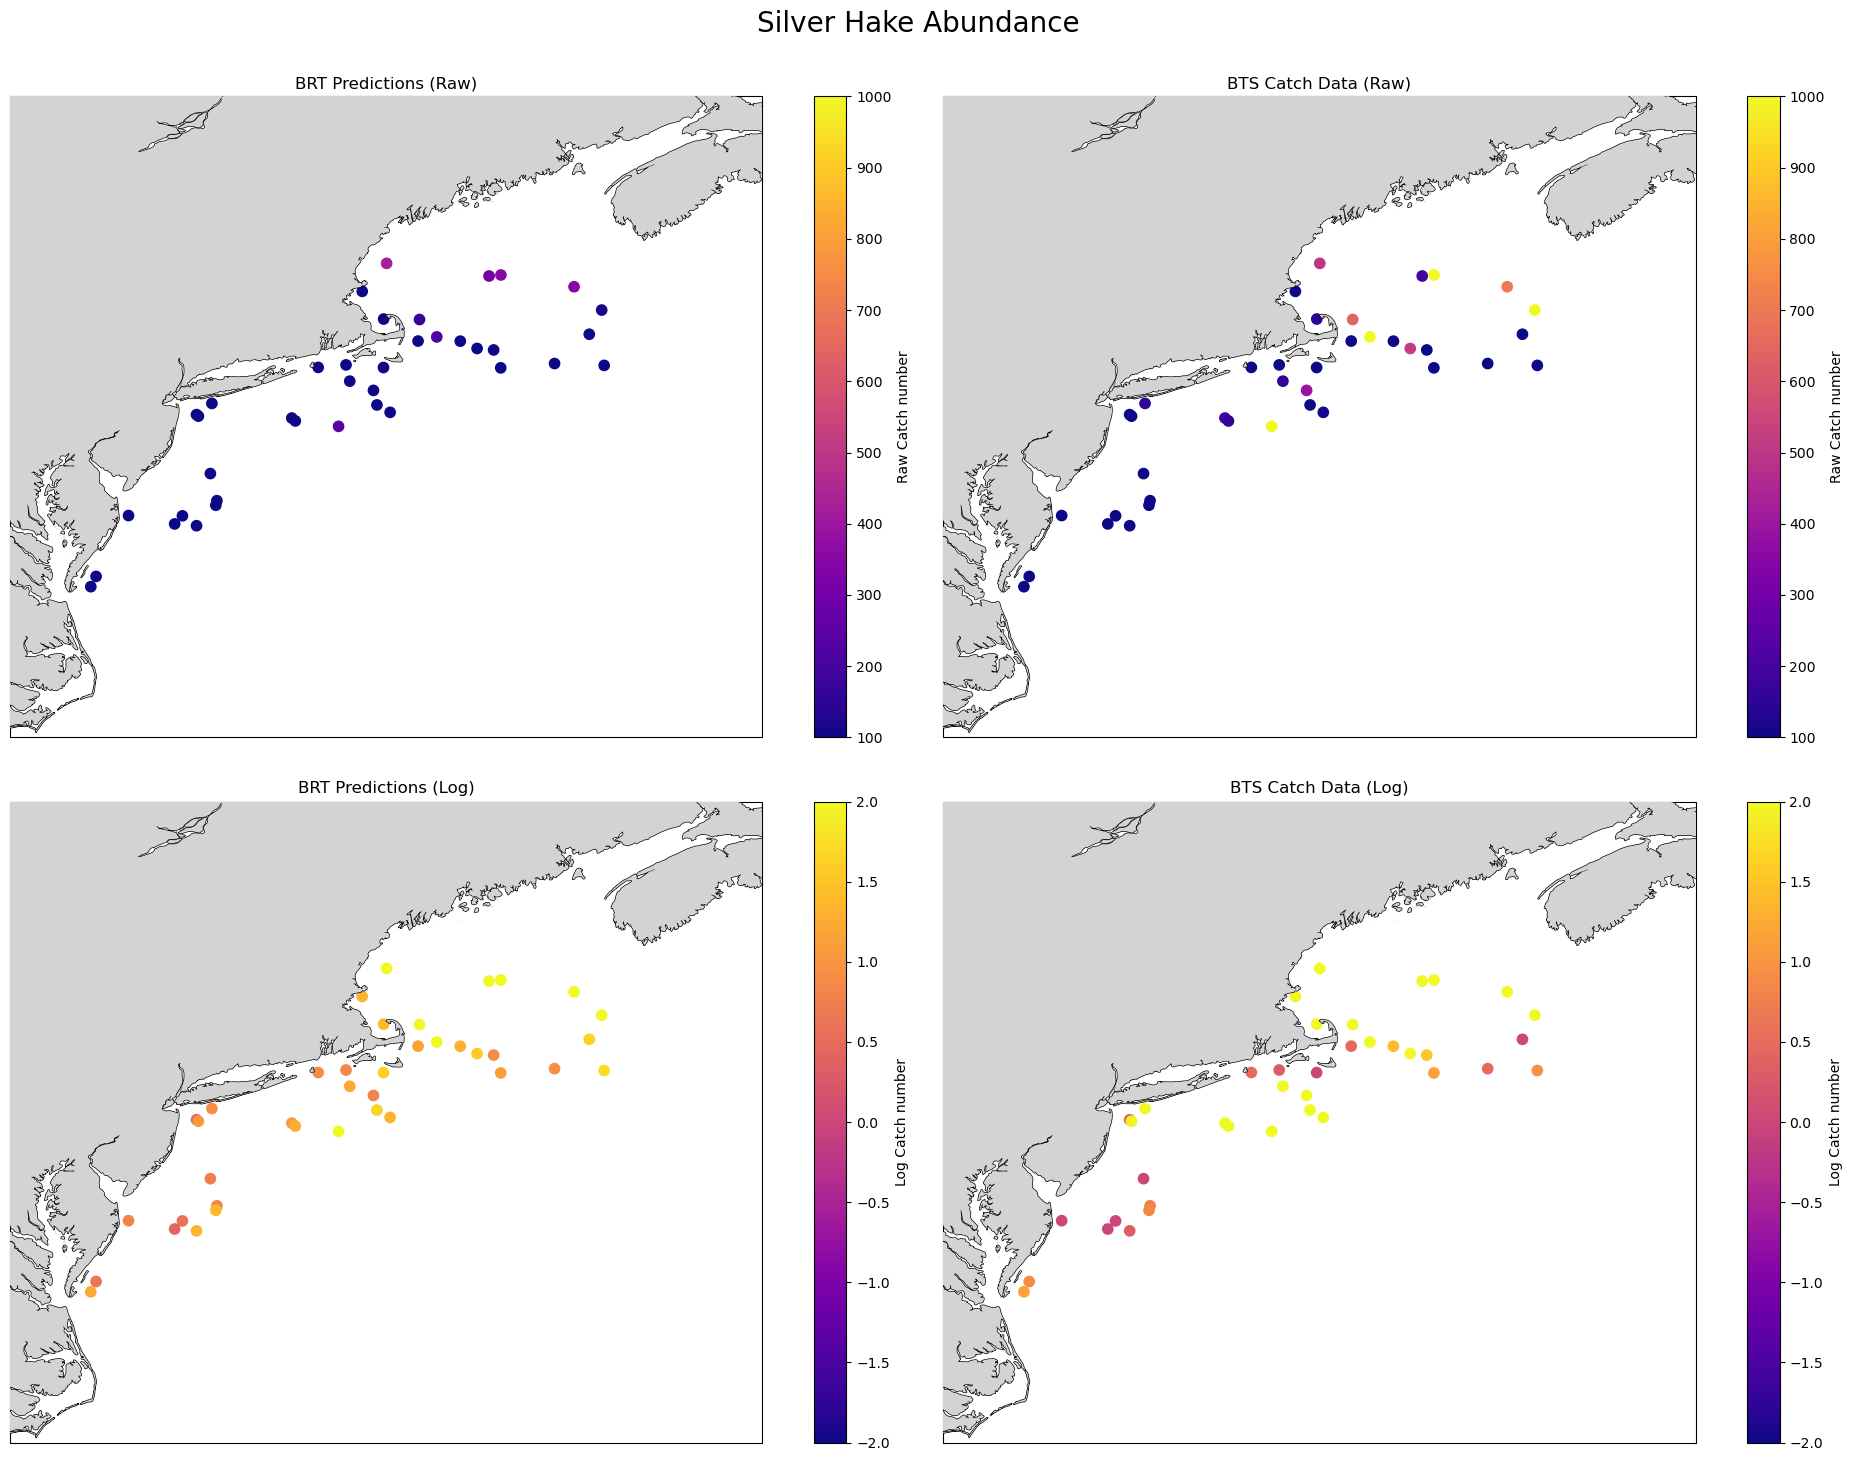

In [22]:
#VISUALIZE PREDICTED ABUNDANCE RESULTS
fig, ax = plt.subplots(nrows=2, ncols=2, subplot_kw={'projection': cartopy.crs.PlateCarree()}, figsize=(20, 14))
ax=ax.flatten()
im1=ax[0].scatter(df.loc[X_test_imputed.index.tolist()].DECDEG_ENDLON, df.loc[X_test_imputed.index.tolist()].DECDEG_ENDLAT, c=np.power(10,predictions_brt),cmap='plasma',s=55,vmin=100,vmax=1000)
ax[0].set_title('BRT Predictions (Raw)')
fig.colorbar(im1, ax=ax[0],label='Raw Catch number')
ax[0].add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax[0].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax[0].set_extent([-77, -63.5, 34.5, 46])

im2=ax[1].scatter(df.loc[X_test_imputed.index.tolist()].DECDEG_ENDLON, df.loc[X_test_imputed.index.tolist()].DECDEG_ENDLAT, c=df.loc[y_test.index.tolist()].EXPCATCHNUM,cmap='plasma',s=55,vmin=100,vmax=1000)
ax[1].set_title('BTS Catch Data (Raw)')
fig.colorbar(im2, ax=ax[1],label='Raw Catch number')
ax[1].add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax[1].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax[1].set_extent([-77, -63.5, 34.5, 46])
#fig.suptitle('Silver Hake Abundance', y=0.6)

im3=ax[2].scatter(df.loc[X_test_imputed.index.tolist()].DECDEG_ENDLON, df.loc[X_test_imputed.index.tolist()].DECDEG_ENDLAT, c=predictions_brt,cmap='plasma',s=55,vmin=-2,vmax=2)
ax[2].set_title('BRT Predictions (Log)')
fig.colorbar(im3, ax=ax[2],label='Log Catch number')
ax[2].add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax[2].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax[2].set_extent([-77, -63.5, 34.5, 46])

im4=ax[3].scatter(df.loc[X_test_imputed.index.tolist()].DECDEG_ENDLON, df.loc[X_test_imputed.index.tolist()].DECDEG_ENDLAT, c=df.loc[y_test.index.tolist()].EXPCATCHNUM_log,cmap='plasma',s=55,vmin=-2,vmax=2)
ax[3].set_title('BTS Catch Data (Log)')
fig.colorbar(im4, ax=ax[3],label='Log Catch number')
ax[3].add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax[3].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax[3].set_extent([-77, -63.5, 34.5, 46])

plt.tight_layout()
plt.subplots_adjust(wspace=-0.1, hspace=0.1)
plt.suptitle('Silver Hake Abundance',y=1.04,fontsize=20)

Text(0.5, 1.0, 'Observed vs Predicted')

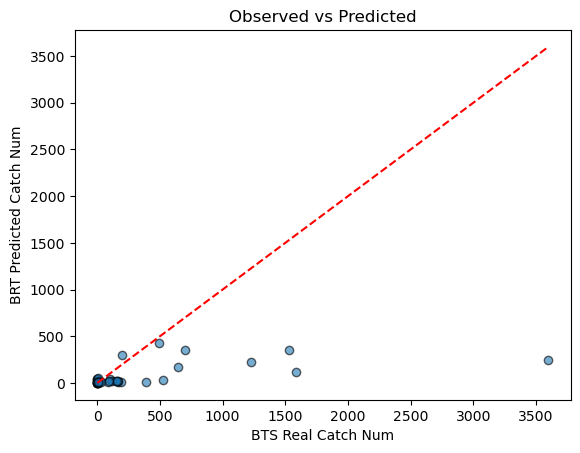

In [25]:

plt.scatter(df.loc[y_test.index.tolist()].EXPCATCHNUM, np.power(10,predictions_brt), alpha=0.6, edgecolor="k")
plt.plot([df.loc[y_test.index.tolist()].EXPCATCHNUM.min(), df.loc[y_test.index.tolist()].EXPCATCHNUM.max()], [df.loc[y_test.index.tolist()].EXPCATCHNUM.min(), df.loc[y_test.index.tolist()].EXPCATCHNUM.max()], "r--")
plt.xlabel("BTS Real Catch Num")
plt.ylabel("BRT Predicted Catch Num")
plt.title("Observed vs Predicted")

#### Mapped residuals <a id="mr"></a>

/tmp/ipykernel_108/316183492.py:25: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1400 with 8 Axes> than <Figure size 1400x700 with 4 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im2, ax=ax3, label='Log residuals (BRT-test)', ticks=ticks,shrink=0.6)


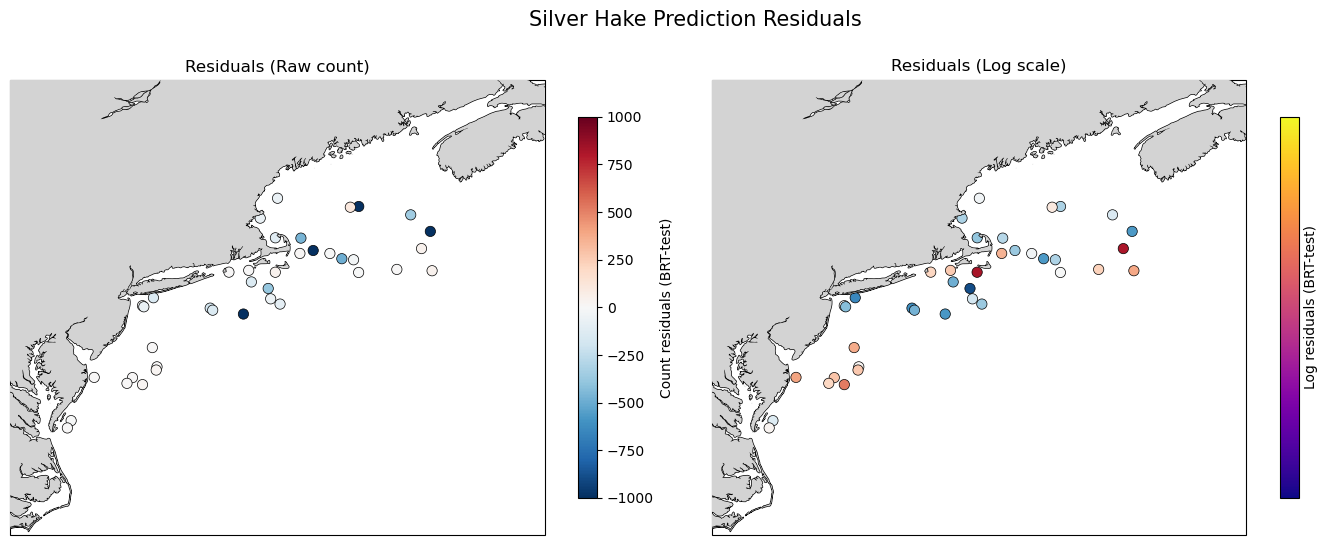

In [26]:
idx = X_test_imputed.index
obs = df.loc[y_test.index, 'EXPCATCHNUM_log']
xgb_resid_log = predictions_brt  - obs

obs = df.loc[y_test.index, 'EXPCATCHNUM']
xgb_resid =np.power(10, predictions_brt) - obs
lons = df.loc[idx, 'DECDEG_ENDLON']
lats = df.loc[idx, 'DECDEG_ENDLAT']

fig, (ax2,ax3) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': cartopy.crs.PlateCarree()}, figsize=(14, 7))
norm = TwoSlopeNorm(vmin=-1000, vcenter=0, vmax=1000)
ticks = [-1000,-500,0,500,1000]
im1=ax2.scatter(lons, lats, c=xgb_resid, s=55, 
                cmap='RdBu_r', norm=norm, transform=ccrs.PlateCarree(),edgecolors='black',linewidth=0.5)
ax2.set_title('Residuals (Raw count)')
fig.colorbar(im1, ax=ax2,shrink=0.6,label='Count residuals (BRT-test)')
ax2.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax2.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax2.set_extent([-77, -63.5, 34.5, 46])



norm_log = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
ticks = [-2,-1.5,-1,-.5,0,.5,1,1.5,2]
cbar = fig.colorbar(im2, ax=ax3, label='Log residuals (BRT-test)', ticks=ticks,shrink=0.6)
im2=ax3.scatter(lons, lats, c=xgb_resid_log, s=55, 
                cmap='RdBu_r', norm=norm_log, transform=ccrs.PlateCarree(),edgecolors='black',linewidth=0.5)
ax3.set_title('Residuals (Log scale)')
#fig.colorbar(im2, ax=ax3,shrink=0.2,label='Log Residuals')
ax3.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax3.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax3.set_extent([-77, -63.5, 34.5, 46])
fig.suptitle('Silver Hake Prediction Residuals', y=0.9,fontsize=15)
plt.tight_layout()


## Interpret results <a id="ir"></a>
### Partial dependence plots <a id="ppd"></a>
How to interpret: <br>
Partial dependence plots isolate the effect of one variable on the model's output. The single variable is on the x-axis, and the model's predicted catch at each value of that variable averaged over all other predictors in the dataset is on the y-axis. <br>
* If the PPD line is flat: the variable has no meaningful effect on the catch
* If the PPD line increases/decreases consistently: there is a consistent relationship between the variable and predicted catch (ie increased temperature = increased catch)
* Hump-shaped curve: there is an optimal range at for catch
* Noisy line: the predictor is weak, there isn't enough data, or the model is overfitting 



Text(0.5, 0.95, 'Partial Dependence plots for BRT')

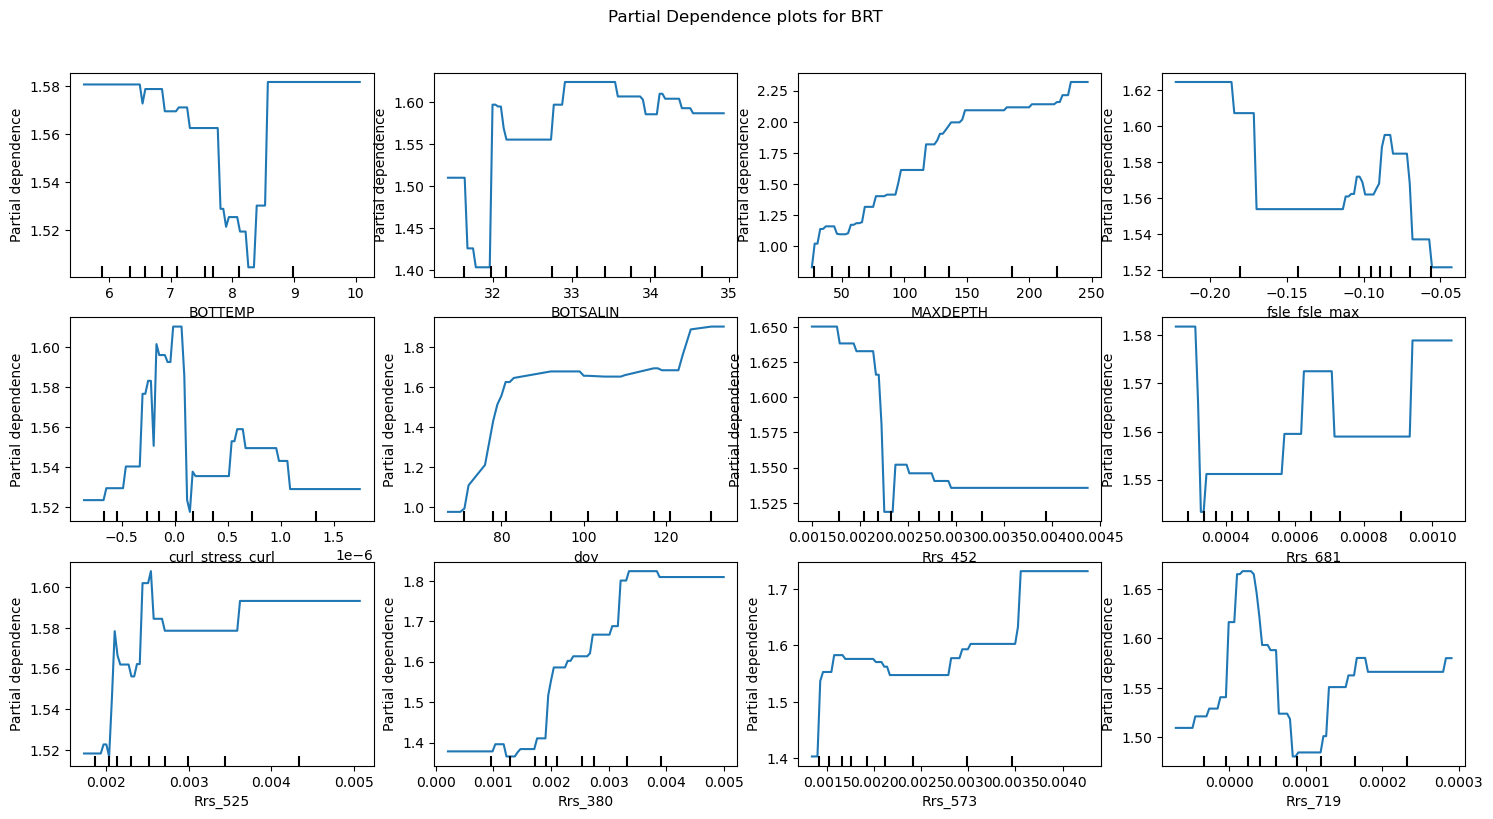

In [27]:
#BOOSTED REGRESSION TREE
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(18, 9))
# Flatten the axs array for easy iteration if needed, though direct indexing works too
axs = axs.flatten()

# Loop through each subplot and plot data
for i, ax in enumerate(axs):
    try: 
        PartialDependenceDisplay.from_estimator(
                            estimator=xgb_reg,
                            X=X_train_imputed[train_vars],
                            features=[X_train_imputed[train_vars].columns[i]],
                            target='EXPCATCHNUM',  
                            ax=ax
                        )
        #ax.set_title(f"{species}")
        ax.set_ylabel("Partial Dependence (log CPUE scale)")
    except IndexError:
        ax.remove()

fig.suptitle('Partial Dependence plots for BRT',y=.95)
#plt.savefig('/home/jovyan/2026-proj-Trawling4PACE/figures/BRT_PPD.jpg')

#### Bland Altman Plots <a id="ba"></a>
Bland Altman plots are a graphical tool to assess agreement between two measurement techniques. The mean difference (bias) line is shown in red and the limit of agreement (LOA) lines are shown in dashed gray lines. A narrow range of LOA means predictions are close to the observations. A wide LOA range means that predictions vary a lot. If the points are scattered around zero, then the model error are stable. If there is a slope, then the error varies with catch size.

Text(0.5, 1.0, 'BTS catch v BRT predictions')

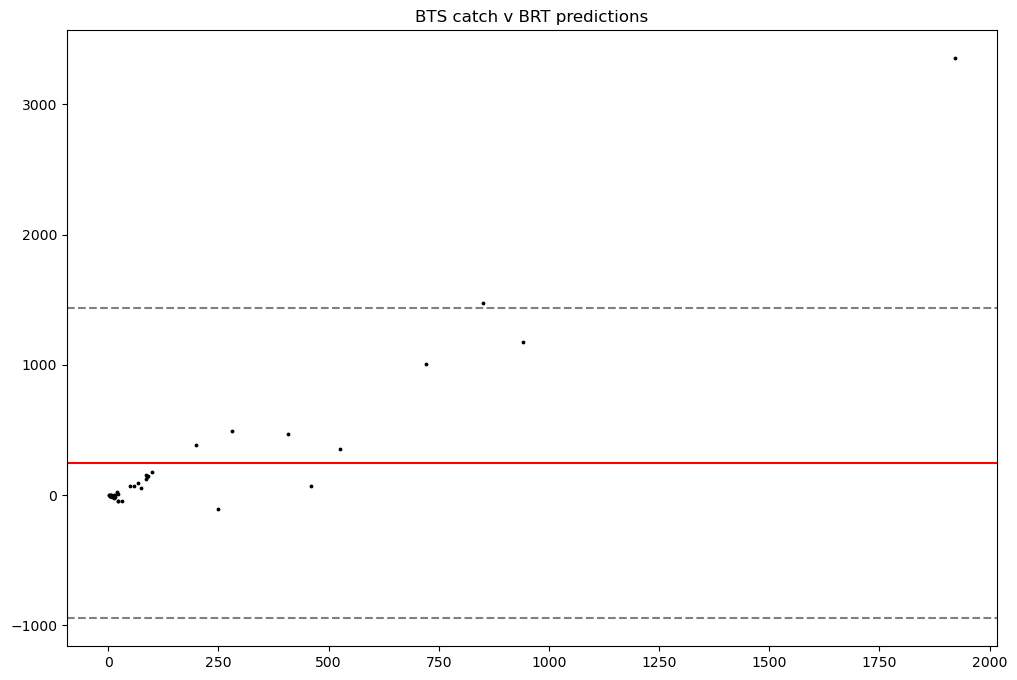

In [31]:
fig = plt.figure(figsize=(12, 8)) #set figure size
x=df.loc[y_test.index.tolist()].EXPCATCHNUM
y=np.power(10,predictions_brt)
differences= x-y
mean= (x+y)/2
plt.scatter(mean, differences,s=3,c='black')
plt.axhline(np.mean(differences), color='red', linestyle='-', label='Mean Diff')
plt.axhline(np.mean(differences) + 1.96*np.std(differences), color='gray', linestyle='--', label='Limits of agreement')
plt.axhline(np.mean(differences) - 1.96*np.std(differences), color='gray', linestyle='--')
plt.title('BTS catch v BRT predictions')

#### Shap values  <a id="shap"></a>
SHAP (SHapley Additive exPLanations) values assign an importance value to each feature for the BRT's prediction, using game theory to explain how much each feature contributes to the difference between the actual prediction and the average prediction. <br>
How to interpret: <br>
The Y-axis shows the features ranked from most important (top) to least important (bottom) impact on the model's predictions. The X-axis depicts the "pull" the feature has on the prediction. Points above 0 pulled the predicted catch higher, points below 0 means the feature pushed the predicted catch lower. The color depicts the features value, with red being high for that variable and blue being low. <br>
Example: 
MAXDEPTH has low values (blue) pulled the catch lower and high MAXDEPTH values pulled the catch prediction higher, meaning that hake were typically caught at deeper depths, not at shallow depths. 

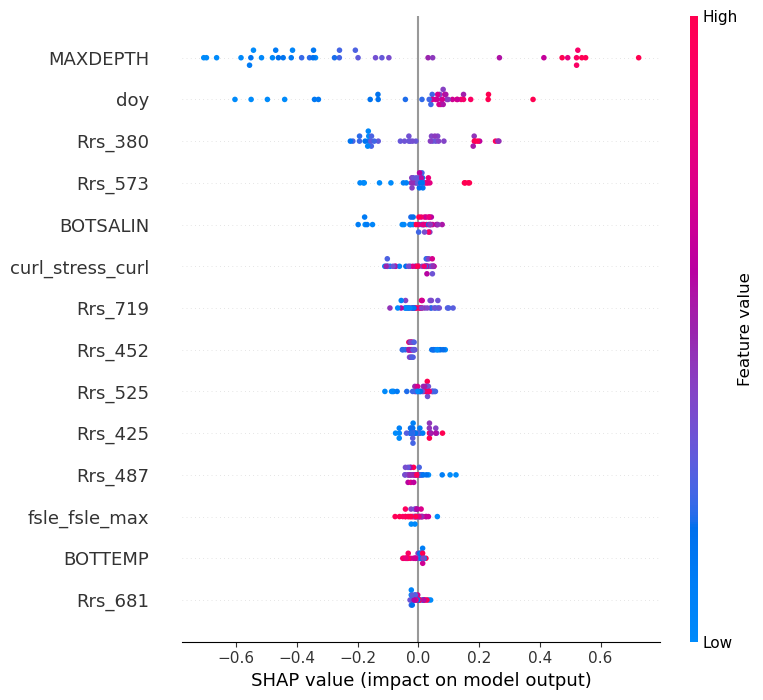

In [28]:
explainer = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_test_imputed[train_vars])
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_imputed[train_vars], plot_type="dot")

## Statistical analysis <a id="sa"></a>

### Check for [overfitting](#overfitting)  <a id="of"></a>
If your training R^2 is really high (>0.9), then it is a good indication that your model is overfitting. Generally if there is a 10-20% difference between your training R^2 and your test R^2, the model is overfitting. 

In [29]:
train_score = xgb_reg.score(X_train_imputed[train_vars], y_train)
test_score = xgb_reg.score(X_test_imputed[train_vars], y_test)
print(f"Train R2: {train_score:.2f}, Test R2: {test_score:.2f}")
if train_score-test_score>.2:
    print('The model is overfitting. Try simplifying the model or increasing regularization')
else:
    print('Congrats! The model is not overfitting')

#hint! try decreasing the max_depth

Train R2: 0.81, Test R2: 0.43
The model is overfitting. Try simplifying the model or increasing regularization


### [K-fold cross validation](#K-fold-cross-validation)  <a id="cv"></a>
Cross-validation is a statistical technique used to evaluate machine learning model performance and ensure it generalizes well to unseen data (in this case we don't have any unseen data, instead we are just giving it ALL the data) <br>
Steps:
1. Splitting the dataset.
2. Training the model on some parts and testing it on the remaining part.
3. Repeating this resampling process multiple times by choosing different parts of the dataset.
4. Averaging the results from each validation step to get the final performance.

In [30]:
# Combine data so KFold can pull from the everything
# This assumes X_train/X_test have the same columns
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test]) # Use the log-transformed catch values

# 2. Reset indices (Critical! Otherwise .iloc vs .loc will cause errors)
X_all = X_all.reset_index(drop=True)
y_all = y_all.reset_index(drop=True)

# 3. Setup the KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

brt_errors = []
brt_rsquare = []

for train_idx, test_idx in kf.split(X_all):
    # Use .iloc to grab the rows based on the current fold's index
    X_train_cv, X_test_cv = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train_cv, y_test_cv = y_all.iloc[train_idx], y_all.iloc[test_idx]

    # Initialize the model inside the loop or clear it
    xgb_reg = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=1)

    # Fit the model
    xgb_reg.fit(X_train_cv, y_train_cv, 
                eval_set=[(X_test_cv, y_test_cv)],
                verbose=False)

    # Predict and Score
    predictions = xgb_reg.predict(X_test_cv)
    
    rmse = np.sqrt(mean_squared_error(y_test_cv, predictions))
    r2 = r2_score(y_test_cv, predictions)
    
    brt_errors.append(rmse)
    brt_rsquare.append(r2)

print(f"Mean RMSE: {np.mean(brt_errors):.4f}")
print(f"Mean R2: {np.mean(brt_rsquare):.4f}")

Mean RMSE: 0.7516
Mean R2: 0.4166


## Conclusions <a id="conc"></a>
**How to improve this model:**
* More catch data
  * options:
     * Wait! BTS is conducted twice a year, in a year or two there will be more data to use for an analysis like this
     * Use multispectral data for a longer time series of satellite data
* Test other satellite-derived variables
  * chl-a, AVW, PAR, MOANA, etc

**Limitations:**
* Use of imputed data
  * Lots of imputed data may have introduced bias and artificial patterns to the dataset, which may have caused the model to learn the characteristics of the imputed values rather than the real data distribution
* Small dataset
  * Due to the small dataset, the model may be memorizing the noise and not the generalizable patterns (overfitting)
* Random training split
  * There is likely data leakage in the that we are splitting the data currently

## Definitions  <a id="def"></a>
*Note: these definitions were just taken from google AI*
* #### Overfitting:
  * Overfitting in machine learning occurs when a model learns training data too specifically—including its noise and outliers—resulting in excellent performance on training data but poor generalization to new, unseen data. It indicates high variance, often caused by excessively complex models, insufficient training data, or overtraining.

* #### Multicollinearity:
  * A situation in regression models where two or more independent variables are highly correlated

* #### Ranking-based feature selection:
  * Feature selection method that scores features based on their relationship to the target variable, ranking them based on Pearson correlation. This helps remove dimensionality and multicollinearity.

* #### Feature:
   * Individual, measurable, and independent properties or characteristics of a dataset used as input to train models for prediction or classification
    
* #### Data leakage: 
  * When dependent data points (time series, grouped, correlated observations) are separated into training and testing sets, allowing the model to learn from future or test-set information
 
* #### K nearest neighbors imputation:
  * Technique that fills in missing values in a dataset by using values from the most similar data points (aka the nearest neighbor)
 
* #### Depth:
  * In the context of decision trees, depth is the length of the longest path from root node to any leaf node. It is measured by the number of edges or splits along that path.

* #### Boosting:
  * In machine learning, boosting is a sequential sequential ensemble machine learning technique that combines multiple weak learners (typically simple decision trees) to create a single, highly accurate "strong learner". Instead of training models in parallel, boosting builds them in succession, where each new model focuses on correcting the errors of the previous ones by increasing the weight of misclassified data points

* #### Decision trees:
  * A supervised machine learning algorithm that uses a hierarchical, flowchart-like structure to make decisions or predictions. It can be used for both classification (predicting categories) and regression (predicting continuous values) tasks. The algorithm works by recursively splitting a dataset into smaller, more homogeneous subsets based on the values of its features. This is recursive partitioning, aiming for the purest possible subsets at the final nodes.
* #### K-fold cross validation
  * A resampling technique used to evaluate machine learning models by splitting data into 10 subsets (folds), training on 9, and testing on 1, repeated 10 times